# Chaper 8 - Intrinsic Curiosity Module
## Deep Reinforcement Learning *in Action*

<b>PyTorch Implementation of Curiosity-Driven Exploration by Self-Supervised Prediction</b>

<b>Trained to play Super Mario Bros. with and without game-generated explicit rewards.</b>

Successfully learns to progress through game with just intrinsic (curiosity) rewards.

- Paper: "Curiosity-driven Exploration by Self-supervised Prediction" Pathak et al 2017

This implementation follows the paper almost exactly, however, we use a Deep Q-network as the agent rather than A3C for simplicity. We also do not utilize an LSTM layer in the Q-network for simplicity and it is unnecessary for Super Mario Brothers. 

You can train this model on a modern laptop for a few thousand iterations (will take 30+ minutes) and can already see interesting results (i.e. the agent will be obviously much better than the random agent, making relatively consistent forward progress, jumping over/on enemies and over obstacles. To match the reference paper's result you will need to train much longer using a GPU.

##### Listing 8.1 - Setting up the Super Mario Bros. environment

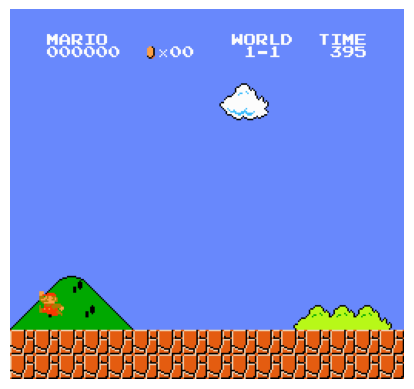

In [1]:
import time
from random import shuffle

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import gym_super_mario_bros as gym
from torch import nn
from torch import optim
from collections import deque
from nes_py.wrappers import JoypadSpace  # A
from IPython.display import clear_output
from gym_super_mario_bros.actions import COMPLEX_MOVEMENT  # B


def show_frame(f):
    plt.imshow(f)
    plt.axis("off")
    plt.show()


env = gym.make("SuperMarioBros-v0", render_mode="rgb_array")
env = JoypadSpace(env, COMPLEX_MOVEMENT)  # C

state, info = env.reset(seed=123)

done = False
for step in range(100):  # D
    state, reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated
    clear_output(wait=True)
    show_frame(env.render())
    if done:
        state, info = env.reset(seed=123)

In [2]:
for i, a in enumerate(env.get_action_meanings()):
    print(f"Action {str(i)} -> {a}")

Action 0 -> NOOP
Action 1 -> right
Action 2 -> right A
Action 3 -> right B
Action 4 -> right A B
Action 5 -> A
Action 6 -> left
Action 7 -> left A
Action 8 -> left B
Action 9 -> left A B
Action 10 -> down
Action 11 -> up


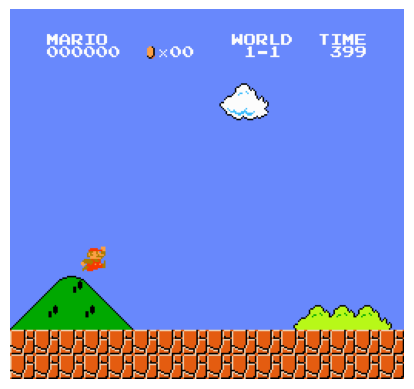

40 -> 47


In [3]:
# You can use this to understand how an action in a step changes the environment for yourself
state, info = env.reset(seed=123)
first_pos = info["x_pos"]
a_second = 20  # A second takes 20 steps
# action_seq = [2] * 15
action_seq = [1] * 6 + [5] * 6
for ai in action_seq:
    state, reward, terminated, truncated, info = env.step(ai)
# Don't press anything for the remainig duration
for i in range(a_second - len(action_seq)):
    state, reward, terminated, truncated, info = env.step(0)
show_frame(env.render())
print(str(first_pos), "->", str(info["x_pos"]))

In [4]:
env.close()

##### Listing 8.2 - Downsample state and convert to grayscale

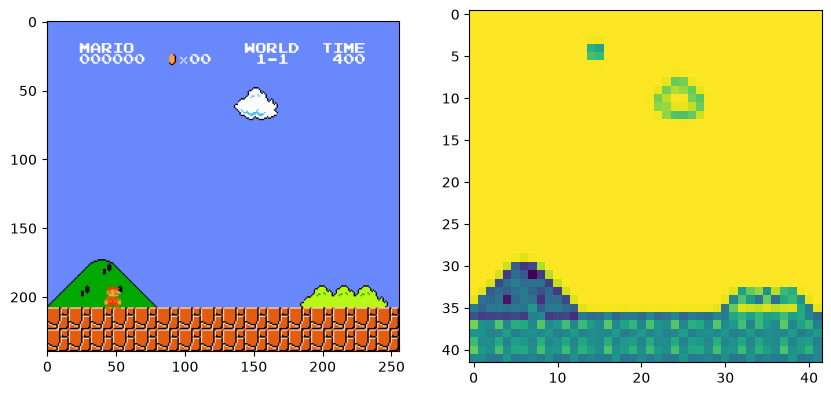

In [5]:
from skimage.transform import resize  # A


def downscale_obs(obs, new_size=(42, 42), to_gray=True):
    """
    downscale_obs: rescales RGB image to lower dimensions with option to change to grayscale

    obs: Numpy array or PyTorch Tensor of dimensions Ht x Wt x 3 (channels)

    to_gray: if True, will use max to sum along channel dimension for greatest contrast
    """
    if to_gray:
        return resize(obs, new_size, anti_aliasing=True).max(axis=2)  # B
    else:
        return resize(obs, new_size, anti_aliasing=True)


env = gym.make("SuperMarioBros-v0", render_mode="rgb_array")
env = JoypadSpace(env, COMPLEX_MOVEMENT)
state, info = env.reset()

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
frame = env.render()
ax[0].imshow(frame)
ax[1].imshow(downscale_obs(frame))
plt.show()

##### Listing 8.3 - Preparing the states

In [6]:
def prepare_state(state):  # A
    """
    First downscale state, convert to grayscale, convert to torch tensor and add batch dimension
    """
    return torch.from_numpy(downscale_obs(state, to_gray=True)).float().unsqueeze(dim=0)


def prepare_multi_state(state1, state2):  # B
    """
    Prepare a 3 channel state (for use in inference not training).

    The Q-model and encoder/Phi model expect the input state to have 3 channels. Following the reference paper,
    these models are fed 3 consecutive state frames to give the model's access to motion information
    (i.e. velocity information rather than just positional information)
    """
    # prev is 1x3x42x42
    state1 = state1.clone()
    tmp = torch.from_numpy(downscale_obs(state2, to_gray=True)).float()
    # shift data along tensor to accomodate newest observation (we could have used deque w/ maxlen 3)
    state1[0][0] = state1[0][1]
    state1[0][1] = state1[0][2]
    state1[0][2] = tmp  # replace last frame
    return state1


def prepare_initial_state(state, N=3):  # C
    """
    Prepares the initial state which is just a tensor of 1 (Batch) x 3 x 42 x 42

    The channel dimension is just a copy of the input state 3 times

    """
    # state should be 42x42 array
    state_ = torch.from_numpy(downscale_obs(state, to_gray=True)).float()
    tmp = state_.repeat((N, 1, 1))  # now 3x42x42
    return tmp.unsqueeze(dim=0)  # now 1x3x42x42

##### Listing 8.4 - The policy function

In [7]:
F.softmax(torch.Tensor([3.6, 4, 3, 2.9, 3.5]), dim=0)

tensor([0.2251, 0.3358, 0.1235, 0.1118, 0.2037])

In [8]:
def policy(qvalues, eps=None):  # A
    """
    policy(qvales, eps=None) takes Q-values and produces an integer representing action

    The function takes a vector of dimension (12,) representing Q-values for each of the 12 discrete actions
    and returns an integer. If `eps` is supplied it follows an epsilon-greedy policy with probability `eps`. If `eps`
    is not supplied, then a softmax policy is used.

    """
    if eps is not None:
        if torch.rand(1) < eps:
            return torch.randint(low=0, high=7, size=(1,))
        else:
            return torch.argmax(qvalues)
    else:
        # B
        return torch.multinomial(F.softmax(F.normalize(qvalues), dim=0), num_samples=1)

##### Listing 8.5 - Experience replay

<b>Experience replay memory</b>

The experience replay memory stores a list of tuples where each tuple is a single experience from an initial state 1, an action taken, the resulting state 2 and reward: $(S_t, a_t, R_{t+1}, S_{t+1})$


The `add_memory(state1, action, reward, state2)` method adds a memory to the memory list. The memory list has a fixed maximum length, if it's full, new memories will randomly overwrite old memories.

The `get_batch()` method returns a random subset from the memory list for training.

In [9]:
class ExperienceReplay:
    def __init__(self, N=500, batch_size=100):
        self.N = N  # A
        self.batch_size = batch_size  # B
        self.memory = []
        self.counter = 0

    def add_memory(self, state1, action, reward, state2):
        self.counter += 1
        if self.counter % 500 == 0:  # C
            self.shuffle_memory()

        if len(self.memory) < self.N:  # D
            self.memory.append((state1, action, reward, state2))
        else:
            rand_index = np.random.randint(0, self.N - 1)
            self.memory[rand_index] = (state1, action, reward, state2)

    def shuffle_memory(self):  # E
        shuffle(self.memory)

    def get_batch(self):  # F
        if len(self.memory) < 1:
            print("Error: No data in memory.")
            return None
        if len(self.memory) < self.batch_size:
            batch_size = len(self.memory)
        else:
            batch_size = self.batch_size
        # G
        ind = np.random.choice(np.arange(len(self.memory)), batch_size, replace=False)
        batch = [self.memory[i] for i in ind]  # batch is a list of tuples
        state1_batch = torch.stack([x[0].squeeze(dim=0) for x in batch], dim=0)
        action_batch = torch.Tensor([x[1] for x in batch]).long()
        reward_batch = torch.Tensor([x[2] for x in batch])
        state2_batch = torch.stack([x[3].squeeze(dim=0) for x in batch], dim=0)
        return state1_batch, action_batch, reward_batch, state2_batch

##### Listing 8.6 - ICM components

<b>Define the Phi (encoder) network</b>
- Input: A state of dimensions Batch x (3) Channels x 42 (Ht) x 42 (Wt)
- Output: Encoded (lower-dimensional) state of dimension Batch x 288

<b>Define Inverse model:  $g(\phi(S_t), \phi(S_{t+1})$</b>
- Input 1: Encoded state1 $\phi(\text{State}_t)$ of dimension Batch x 288
- Input 2: Encoded state2 $\phi(\text{State}_{t+1})$
- Output: Predicted action that was taken to get from $S_t$ to $S_{t+1}$. That is, a softmax over actions, dimensions Batch x 12 (for 12 discrete actions)

<b>Define Forward Model:  $f(\phi(s_t), a_t)$</b>
- Input 1: Encoded state \phi(s_t) of dimension Batch x 288
- Input 2: (Integer-encoded 0-11 for 12 discrete actions) action of dimension Batch x 12
- Output: Predicted encoded next state $\phi(s_{t+1})$

In [10]:
class Phi(nn.Module):  # A
    def __init__(self):
        super(Phi, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=(3, 3), stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=2, padding=1)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=2, padding=1)

    def forward(self, x):
        x = F.normalize(x)
        y = F.elu(self.conv1(x))
        y = F.elu(self.conv2(y))
        y = F.elu(self.conv3(y))
        y = F.elu(self.conv4(y))  # size [1, 32, 3, 3] batch, channels, 3 x 3
        y = y.flatten(start_dim=1)  # size N, 288
        return y


class Gnet(nn.Module):  # B
    def __init__(self):
        super(Gnet, self).__init__()
        self.linear1 = nn.Linear(576, 256)
        self.linear2 = nn.Linear(256, 12)

    def forward(self, state1, state2):
        x = torch.cat((state1, state2), dim=1)
        y = F.relu(self.linear1(x))
        y = self.linear2(y)
        y = F.softmax(y, dim=1)
        return y


class Fnet(nn.Module):  # C
    def __init__(self):
        super(Fnet, self).__init__()
        self.linear1 = nn.Linear(300, 256)
        self.linear2 = nn.Linear(256, 288)

    def forward(self, state, action):
        action_ = torch.zeros(action.shape[0], 12)  # D
        indices = torch.stack((torch.arange(action.shape[0]), action.squeeze()), dim=0)
        indices = indices.tolist()
        action_[tuple(indices)] = 1.0
        x = torch.cat((state, action_), dim=1)
        y = F.relu(self.linear1(x))
        y = self.linear2(y)
        return y

##### Listing 8.7 - Deep Q-network

<b>Define the Q-network module</b>

- Input: x (Tensor dims: Batch x (3) Channels x (42) Ht x (42) Wt
- Output: Batch x 12 (Q values per action)

In [11]:
class Qnetwork(nn.Module):
    def __init__(self):
        super(Qnetwork, self).__init__()
        # in_channels, out_channels, kernel_size, stride=1, padding=0
        self.conv1 = nn.Conv2d(
            in_channels=3, out_channels=32, kernel_size=(3, 3), stride=2, padding=1
        )
        self.conv2 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=2, padding=1)
        self.conv4 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=2, padding=1)
        self.linear1 = nn.Linear(288, 100)
        self.linear2 = nn.Linear(100, 12)

    def forward(self, x):
        x = F.normalize(x)
        y = F.elu(self.conv1(x))
        y = F.elu(self.conv2(y))
        y = F.elu(self.conv3(y))
        y = F.elu(self.conv4(y))
        y = y.flatten(start_dim=2)
        y = y.view(y.shape[0], -1, 32)
        y = y.flatten(start_dim=1)
        y = F.elu(self.linear1(y))
        y = self.linear2(y)  # size N, 12
        return y

##### Listing 8.8 - Hyperparameters and model instantiation


In [12]:
params = {
    "batch_size": 150,
    "beta": 0.2,
    "lambda": 0.1,
    "eta": 1.0,
    "gamma": 0.2,
    "max_episode_len": 100,
    "min_progress": 15,
    "action_repeats": 6,
    "frames_per_state": 3,
}

replay = ExperienceReplay(N=1000, batch_size=params["batch_size"])
Qmodel = Qnetwork()
encoder = Phi()
forward_model = Fnet()
inverse_model = Gnet()
forward_loss = nn.MSELoss(reduction="none")
inverse_loss = nn.CrossEntropyLoss(reduction="none")
qloss = nn.MSELoss()
all_model_params = list(Qmodel.parameters()) + list(encoder.parameters())  # A
all_model_params += list(forward_model.parameters()) + list(inverse_model.parameters())
opt = optim.Adam(lr=0.0001, params=all_model_params)

##### Listing 8.9 - The loss function and reset environment

In [13]:
def loss_fn(q_loss, inverse_loss, forward_loss):
    """
    Overall loss function to optimize for all 4 modules

    Loss function based on calculation in paper
    """
    loss_ = (1 - params["beta"]) * inverse_loss
    loss_ += params["beta"] * forward_loss
    loss_ = loss_.sum() / loss_.flatten().shape[0]
    loss = loss_ + params["lambda"] * q_loss
    return loss


def reset_env():
    """
    Reset the environment and return a new initial state

    Starting x position is not really 0
    """
    state, info = env.reset()
    state = prepare_initial_state(state)
    return state, info["x_pos"]

##### Listing 8.10 - The ICM prediction error calculation

In [14]:
def ICM(state1, action, state2, forward_scale=1.0, inverse_scale=1e4):
    """
    Intrinsic Curiosity Module (ICM): Calculates prediction error for forward and inverse dynamics

    The ICM takes a state1, the action that was taken, and the resulting state2 as inputs
    (from experience replay memory) and uses the forward and inverse models to calculate the prediction error
    and train the encoder to only pay attention to details in the environment that are controll-able (i.e. it should
    learn to ignore useless stochasticity in the environment and not encode that).

    """
    state1_hat = encoder(state1)  # A
    state2_hat = encoder(state2)
    state2_hat_pred = forward_model(state1_hat.detach(), action.detach())  # B
    forward_pred_err = forward_scale * forward_loss(
        state2_hat_pred, state2_hat.detach()
    ).sum(dim=1).unsqueeze(dim=1)
    pred_action = inverse_model(state1_hat, state2_hat)  # C
    inverse_pred_err = inverse_scale * inverse_loss(
        pred_action, action.detach().flatten()
    ).unsqueeze(dim=1)
    return forward_pred_err, inverse_pred_err

##### Listing 8.11 - Mini-batch training using experience replay

This code extracts a minibatch from the experience replay memory and runs the 4 modules forward and calculates the prediction errors for each, returning them as output.

If `use_extrinsic` is set to `True` then the reward will include the game-generated explicit reward. If set to `False` then the agent will learn only based on the instrinsic (curiosity) based prediction-error reward.

In [15]:
def minibatch_train(use_extrinsic=True):
    state1_batch, action_batch, reward_batch, state2_batch = replay.get_batch()
    action_batch = action_batch.view(action_batch.shape[0], 1)  # A
    reward_batch = reward_batch.view(reward_batch.shape[0], 1)

    forward_pred_err, inverse_pred_err = ICM(
        state1_batch, action_batch, state2_batch
    )  # B
    i_reward = (1.0 / params["eta"]) * forward_pred_err  # C
    reward = i_reward.detach()  # D
    if use_extrinsic:  # E
        reward += reward_batch
    qvals = Qmodel(state2_batch)  # F
    reward += params["gamma"] * torch.max(qvals)
    reward_pred = Qmodel(state1_batch)
    reward_target = reward_pred.clone()
    indices = torch.stack(
        (torch.arange(action_batch.shape[0]), action_batch.squeeze()), dim=0
    )
    indices = indices.tolist()
    reward_target[tuple(indices)] = reward.squeeze()
    q_loss = 1e5 * qloss(F.normalize(reward_pred), F.normalize(reward_target.detach()))
    return forward_pred_err, inverse_pred_err, q_loss

##### Listing 8.12 - The training loop

<b>Main Training Loop</b>

Training details to note:
- Training starts with softmax action policy, and then after 1000 steps (or whatever you set it to) it will switch to 
epsilon greedy policy. This empirically seems to help with exploration in the beginning and then epsilon-greedy helps increase the explotation. You should try starting with a softmax policy and increase the temperature slowly during training to make a continuous/smooth version of this approach.

- We use a deque (a list-like data structure where we can specify a maximum length, append items and old items will
automatically get pushed out once the max len is hit) to store the last 3 frames and then package it into a tensor for use as the state.

- We keep track of the `last_x_pos` from the prior `max_episode_len` frames. If the agent hasn't made significant forward progress (x_now - last_x_pos) > 10 then we assume the agent is stuck and we reset the environment.

- Following the reference paper, we use deterministic sticky-actions such that if the policy says do action 0, then we repeat that action 6 times (only during training, during inference we just take the action once). This helps since each action is a very small step in any direction so by compounding them in training the agent can learn faster what the actions are doing.

- If you train with intrinsic reward only, this implementation is not very stable. Sometimes the agent just repeatedly does something stupid and will not learn, and other times it will do very well.

In [16]:
epochs = 5000
state1, last_x_pos = reset_env()  # A
eps = 0.15
losses = []
episode_length = 0
switch_to_eps_greedy = 1000
state_deque = deque(maxlen=params["frames_per_state"])
ep_lengths = []
use_extrinsic = False
for i in range(epochs):
    opt.zero_grad()
    episode_length += 1
    q_val_pred = Qmodel(state1)  # B
    if i > switch_to_eps_greedy:  # C
        action = int(policy(q_val_pred, eps))
    else:
        action = int(policy(q_val_pred))

    e_reward = 0
    for j in range(params["action_repeats"]):  # D
        state2, e_reward_, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if done:
            break
        e_reward += e_reward_
        state_deque.append(prepare_state(state2))
    state2 = torch.stack(list(state_deque), dim=1)  # E
    replay.add_memory(state1, action, e_reward, state2)  # F

    if episode_length > params["max_episode_len"]:  # G
        if (info["x_pos"] - last_x_pos) < params["min_progress"]:
            done = True

    if done:
        ep_lengths.append(last_x_pos)
        state1, last_x_pos = reset_env()
        episode_length = 0
    else:
        state1 = state2
        last_x_pos = info["x_pos"]

    # Enter mini-batch training
    if len(replay.memory) < params["batch_size"]:
        continue
    forward_pred_err, inverse_pred_err, q_loss = minibatch_train(
        use_extrinsic=use_extrinsic
    )  # H
    loss = loss_fn(q_loss, inverse_pred_err, forward_pred_err)  # I
    loss.backward()
    opt.step()
    loss_list = (
        float(q_loss.mean().detach()),
        float(forward_pred_err.flatten().mean().detach()),
        float(inverse_pred_err.flatten().mean().detach()),
    )
    losses.append(loss_list)

    if i % 250 == 0:
        print(f"Epoch {i}, Loss: {loss:.2f}")
        print(
            f"\tForward loss: {loss_list[1]:.2f}, Inverse loss: {loss_list[2]:.2f}, Qloss: {loss_list[0]:.2f}"
        )
        # print(info)

Epoch 250, Loss: 19878.17
	Forward loss: 0.30, Inverse loss: 24819.99, Qloss: 221.17
Epoch 500, Loss: 19793.96
	Forward loss: 0.05, Inverse loss: 24720.80, Qloss: 173.05
Epoch 750, Loss: 19864.58
	Forward loss: 0.03, Inverse loss: 24803.89, Qloss: 214.56
Epoch 1000, Loss: 19929.79
	Forward loss: 0.04, Inverse loss: 24881.61, Qloss: 244.90
Epoch 1250, Loss: 19898.95
	Forward loss: 0.02, Inverse loss: 24831.29, Qloss: 339.20
Epoch 1500, Loss: 19919.65
	Forward loss: 0.01, Inverse loss: 24851.48, Qloss: 384.60
Epoch 1750, Loss: 19901.93
	Forward loss: 0.01, Inverse loss: 24829.75, Qloss: 381.28
Epoch 2000, Loss: 19922.63
	Forward loss: 0.01, Inverse loss: 24855.80, Qloss: 379.87
Epoch 2250, Loss: 19913.02
	Forward loss: 0.01, Inverse loss: 24844.96, Qloss: 370.51
Epoch 2500, Loss: 19906.89
	Forward loss: 0.04, Inverse loss: 24845.96, Qloss: 301.14
Epoch 2750, Loss: 19914.67
	Forward loss: 0.02, Inverse loss: 24851.51, Qloss: 334.55
Epoch 3000, Loss: 19916.33
	Forward loss: 0.02, Inverse l

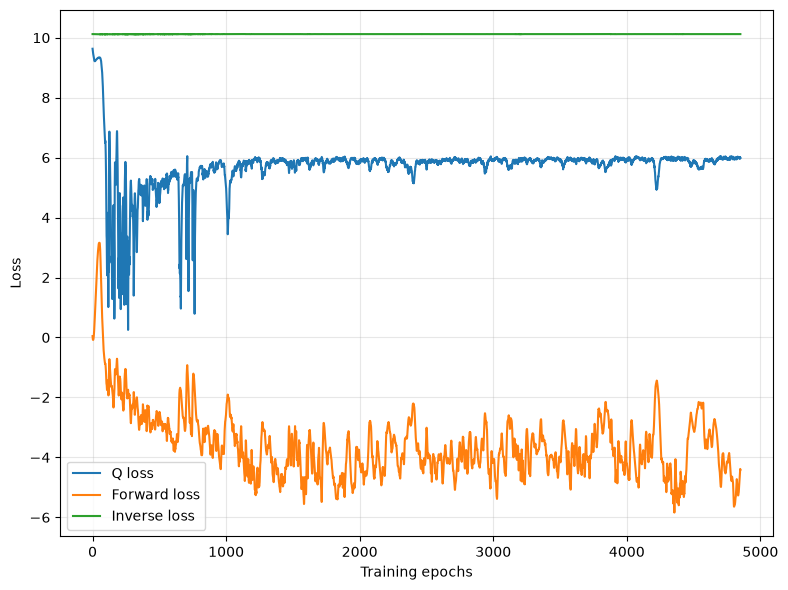

In [17]:
losses_ = np.array(losses)
plt.figure(figsize=(8, 6))
plt.plot(np.log(losses_[:, 0]), label="Q loss")
plt.plot(np.log(losses_[:, 1]), label="Forward loss")
plt.plot(np.log(losses_[:, 2]), label="Inverse loss")

plt.xlabel("Training epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

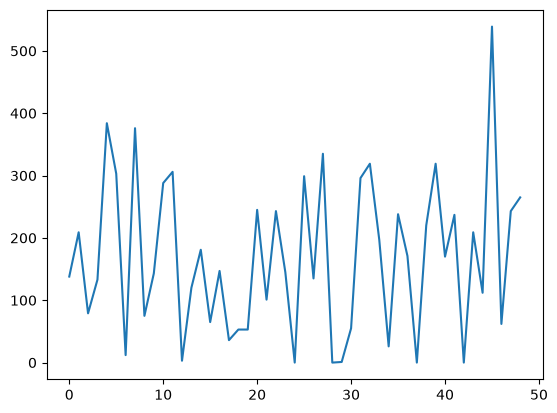

In [18]:
plt.figure()
plt.plot(np.array(ep_lengths), label="Episode length")

##### Listing 8.13 - Testing the trained agent

In [19]:
env = gym.make("SuperMarioBros-v0", render_mode="human")
env = JoypadSpace(env, COMPLEX_MOVEMENT)

state1, info = env.reset(seed=123)
state1 = prepare_initial_state(state1)

done = False
while not done:
    q_val_pred = Qmodel(state1)
    action = int(policy(q_val_pred, eps))

    state2, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated or info["time"] == 0

    state2 = prepare_multi_state(state1, state2)
    state1 = state2

    env.render()

env.close()

# References

- "Curiosity-driven Exploration by Self-supervised Prediction" Pathak et al 2017